# Primeiro notebook (visualização de dados e análise de corridas)

In [48]:
import csv

def load_csv(path):
    with open(path, 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        return list(reader)

races = load_csv('../data/raw/races.csv')
lap_times = load_csv('../data/raw/lap_times.csv')
drivers = load_csv('../data/raw/drivers.csv')

## Pega exemplos de dados

In [49]:
print(f"Corridas: {len(races)}")
print(f"Voltas: {len(lap_times)}")
print(f"Pilotos: {len(drivers)}")

print("\n--- Exemplo de linha ---")
print("Race:", races[0])
print("Lap:", lap_times[0])
print("Driver:", drivers[0])

Corridas: 1125
Voltas: 589081
Pilotos: 861

--- Exemplo de linha ---
Race: {'raceId': '1', 'year': '2009', 'round': '1', 'circuitId': '1', 'name': 'Australian Grand Prix', 'date': '2009-03-29', 'time': '06:00:00', 'url': 'http://en.wikipedia.org/wiki/2009_Australian_Grand_Prix', 'fp1_date': '\\N', 'fp1_time': '\\N', 'fp2_date': '\\N', 'fp2_time': '\\N', 'fp3_date': '\\N', 'fp3_time': '\\N', 'quali_date': '\\N', 'quali_time': '\\N', 'sprint_date': '\\N', 'sprint_time': '\\N'}
Lap: {'raceId': '841', 'driverId': '20', 'lap': '1', 'position': '1', 'time': '1:38.109', 'milliseconds': '98109'}
Driver: {'driverId': '1', 'driverRef': 'hamilton', 'number': '44', 'code': 'HAM', 'forename': 'Lewis', 'surname': 'Hamilton', 'dob': '1985-01-07', 'nationality': 'British', 'url': 'http://en.wikipedia.org/wiki/Lewis_Hamilton'}


# Gráfico 1: distribuição dos dados
- Baseia-se em quantas voltas existem no dataset em cada posição da corrida

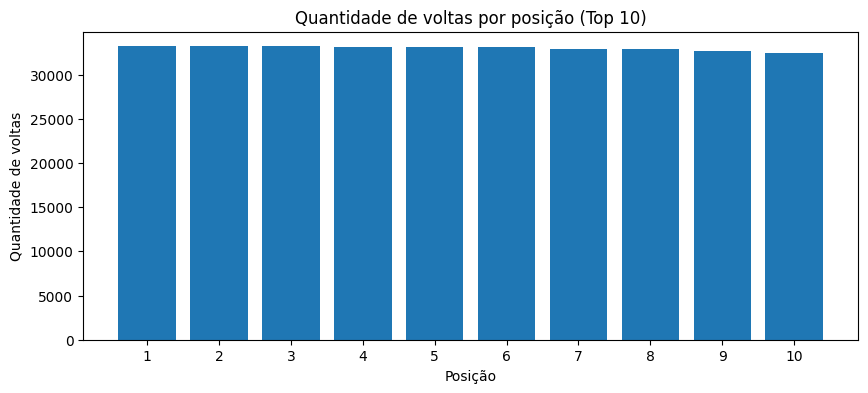

In [63]:
import matplotlib.pyplot as plt

posicoes = {}
for volta in lap_times:
    pos = volta['position']
    posicoes[pos] = posicoes.get(pos, 0) + 1
    
posicoes_ordenadas = sorted(posicoes.items(), key=lambda x: int(x[0]))[:10]
labels = [p[0] for p in posicoes_ordenadas]
valores = [p[1] for p in posicoes_ordenadas]

plt.figure(figsize=(10, 4))
plt.bar(labels, valores)
plt.title('Quantidade de voltas por posição (Top 10)')
plt.xlabel('Posição')
plt.ylabel('Quantidade de voltas')
plt.show()

# Gráfico 2: Top 10 pilotos com mais voltas na liderança

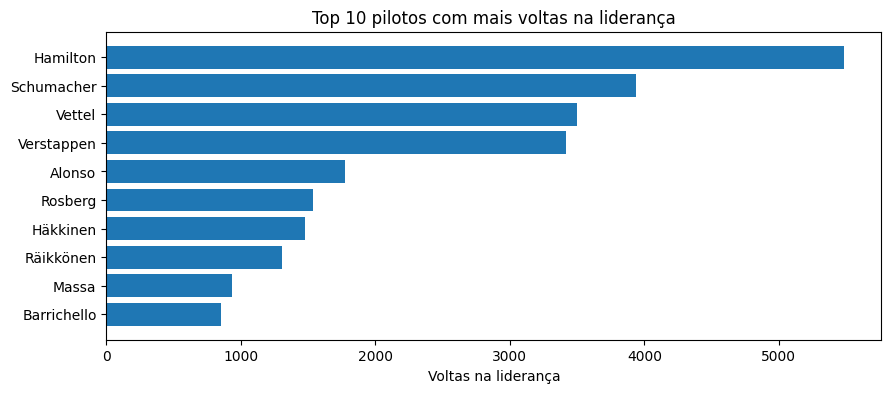

In [ ]:

driver_map = {d['driverId']: d['surname'] for d in drivers}

liderancas = {}
for volta in lap_times:
    if volta['position'] == '1':
        did = volta['driverId']
        liderancas[did] = liderancas.get(did, 0) + 1

top10 = sorted(liderancas.items(), key=lambda x: x[1], reverse=True)[:10]
nomes = [driver_map.get(d[0], d[0]) for d in top10]
voltas = [d[1] for d in top10]

plt.figure(figsize=(10, 4))
plt.barh(nomes, voltas)
plt.title('Top 10 pilotos com mais voltas na liderança')
plt.xlabel('Voltas na liderança')
plt.gca().invert_yaxis()
plt.show()

# Gráfico 3: Evolução de posição de um piloto numa corrida

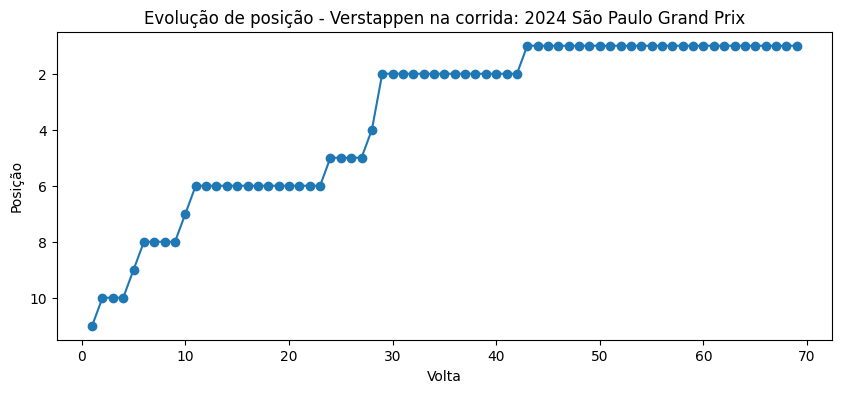

In [ ]:

# Verstappen (driverId=830) na corrida de id 1141
corrida_id = '1141'
driver_id = '830'

voltas_corrida = [v for v in lap_times if v['raceId'] == corrida_id and v['driverId'] == driver_id]
voltas_corrida.sort(key=lambda x: int(x['lap']))

laps = [int(v['lap']) for v in voltas_corrida]
posicoes_corrida = [int(v['position']) for v in voltas_corrida]
nome_piloto = driver_map.get(driver_id, driver_id)


race_map = {r['raceId']: r['year'] + ' ' + r['name'] for r in races}


plt.figure(figsize=(10, 4))
plt.plot(laps, posicoes_corrida, marker='o')
plt.title(f'Evolução de posição - {nome_piloto} na corrida: {race_map.get(corrida_id, corrida_id)}')
plt.xlabel('Volta')
plt.ylabel('Posição')
plt.gca().invert_yaxis()
plt.show()

# Tentativa de predição de posição de chegada usando dados da volta (em ms)

## 1. Extrair apenas o que precisamos

In [ ]:

dados = []
for volta in lap_times:
    ms = volta['milliseconds']
    lap = volta['lap']
    pos = volta['position']
    
    # ignorar linhas com dados faltando
    if ms == '\\N' or lap == '\\N' or pos == '\\N':
        continue
    
    dados.append({
        'ms': int(ms),
        'lap': int(lap),
        'target': 1 if pos == '1' else 0
    })

print(f"Total de amostras: {len(dados)}")
print(f"Na liderança (1): {sum(d['target'] == 1 for d in dados)}")
print(f"Fora da liderança (0): {sum(d['target'] == 0 for d in dados)}")

Total de amostras: 589081
Na liderança (1): 33196
Fora da liderança (0): 555885


## 2. Separar as classes

In [ ]:

classe_1 = [d for d in dados if d['target'] == 1]
classe_0 = [d for d in dados if d['target'] == 0]



Total balanceado: 66392
Classe 1: 33196
Classe 0: 33196


## 3. Balancear pegando a mesma quantidade de cada classe

In [ ]:

import random
random.seed(42)

quantidade = len(classe_1)  # 33196
classe_0_balanceada = random.sample(classe_0, quantidade)

dados_balanceados = classe_1 + classe_0_balanceada
random.shuffle(dados_balanceados)

print(f"Total balanceado: {len(dados_balanceados)}")
print(f"Classe 1: {sum(d['target'] == 1 for d in dados_balanceados)}")
print(f"Classe 0: {sum(d['target'] == 0 for d in dados_balanceados)}")

## Normalização manual (sem numpy)

In [ ]:

def normalizar(lista):
    minv = min(lista)
    maxv = max(lista)
    return [(x - minv) / (maxv - minv) for x in lista]

ms_raw  = [d['ms']  for d in dados_balanceados]
lap_raw = [d['lap'] for d in dados_balanceados]
targets = [d['target'] for d in dados_balanceados]

ms_norm  = normalizar(ms_raw)
lap_norm = normalizar(lap_raw)

# Montar X e y
X = [[ms_norm[i], lap_norm[i]] for i in range(len(dados_balanceados))]
y = targets

print(f"Exemplo de entrada: {X[0]}")
print(f"Target: {y[0]}")

Exemplo de entrada: [0.004786823628225424, 0.36046511627906974]
Target: 0


## Divisão dos dados:
- 80% treino, 20% teste (sem sklearn)

In [ ]:

split = int(len(X) * 0.8)

X_treino = X[:split]
y_treino = y[:split]

X_teste = X[split:]
y_teste = y[split:]

print(f"Treino: {len(X_treino)} amostras")
print(f"Teste:  {len(X_teste)} amostras")

Treino: 53113 amostras
Teste:  13279 amostras


In [70]:
# Função de ativação degrau
def degrau(soma):
    return 1 if soma >= 0 else 0

# Treinamento
def treinar_perceptron(X, y, taxa=0.1, epocas=100):
    w = [0.0, 0.0]  # pesos para ms e lap
    b = 0.0          # bias
    historico_erro = []

    for epoca in range(epocas):
        total_erro = 0
        for i in range(len(X)):
            soma = w[0]*X[i][0] + w[1]*X[i][1] + b
            pred = degrau(soma)
            erro = y[i] - pred
            w[0] += taxa * erro * X[i][0]
            w[1] += taxa * erro * X[i][1]
            b    += taxa * erro
            total_erro += abs(erro)
        
        historico_erro.append(total_erro)
        if epoca % 10 == 0:
            print(f"Época {epoca} - Erros: {total_erro}")

    return w, b, historico_erro

w, b, historico = treinar_perceptron(X_treino, y_treino)

Época 0 - Erros: 26497
Época 10 - Erros: 26456
Época 20 - Erros: 26386
Época 30 - Erros: 26410
Época 40 - Erros: 26468
Época 50 - Erros: 26432
Época 60 - Erros: 26416
Época 70 - Erros: 26464
Época 80 - Erros: 26436
Época 90 - Erros: 26466


## Testes 1

In [71]:
# Avaliação no conjunto de teste
def avaliar(X, y, w, b):
    acertos = 0
    for i in range(len(X)):
        soma = w[0]*X[i][0] + w[1]*X[i][1] + b
        pred = degrau(soma)
        if pred == y[i]:
            acertos += 1
    return acertos / len(y)

acuracia = avaliar(X_teste, y_teste, w, b)
print(f"Acurácia no teste: {acuracia:.2%}")

Acurácia no teste: 49.57%


## Calcular tempo médio por corrida

In [ ]:

media_por_corrida = {}
for volta in lap_times:
    if volta['milliseconds'] == '\\N':
        continue
    rid = volta['raceId']
    ms = int(volta['milliseconds'])
    if rid not in media_por_corrida:
        media_por_corrida[rid] = []
    media_por_corrida[rid].append(ms)

for rid in media_por_corrida:
    vals = media_por_corrida[rid]
    media_por_corrida[rid] = sum(vals) / len(vals)

# Recriar dados com nova feature: ms relativo à média da corrida
dados2 = []
for volta in lap_times:
    ms = volta['milliseconds']
    lap = volta['lap']
    pos = volta['position']
    rid = volta['raceId']

    if ms == '\\N' or lap == '\\N' or pos == '\\N':
        continue

    ms = int(ms)
    media = media_por_corrida[rid]
    ms_relativo = ms / media  # <1 = volta rápida, >1 = volta lenta

    dados2.append({
        'ms_relativo': ms_relativo,
        'lap': int(lap),
        'target': 1 if pos == '1' else 0
    })

In [73]:
classe_1 = [d for d in dados2 if d['target'] == 1]
classe_0 = [d for d in dados2 if d['target'] == 0]

random.seed(42)
classe_0_balanceada = random.sample(classe_0, len(classe_1))
dados_balanceados2 = classe_1 + classe_0_balanceada
random.shuffle(dados_balanceados2)

In [74]:
ms_raw2  = [d['ms_relativo'] for d in dados_balanceados2]
lap_raw2 = [d['lap'] for d in dados_balanceados2]
targets2 = [d['target'] for d in dados_balanceados2]

ms_norm2  = normalizar(ms_raw2)
lap_norm2 = normalizar(lap_raw2)

X2 = [[ms_norm2[i], lap_norm2[i]] for i in range(len(dados_balanceados2))]
y2 = targets2

# Resultados:

In [75]:
split2 = int(len(X2) * 0.8)
X_treino2, y_treino2 = X2[:split2], y2[:split2]
X_teste2,  y_teste2  = X2[split2:], y2[split2:]

w2, b2, historico2 = treinar_perceptron(X_treino2, y_treino2)

acuracia2 = avaliar(X_teste2, y_teste2, w2, b2)
print(f"Acurácia nova: {acuracia2:.2%}")

Época 0 - Erros: 26421
Época 10 - Erros: 26444
Época 20 - Erros: 26438
Época 30 - Erros: 26436
Época 40 - Erros: 26436
Época 50 - Erros: 26422
Época 60 - Erros: 26436
Época 70 - Erros: 26444
Época 80 - Erros: 26438
Época 90 - Erros: 26442
Acurácia nova: 49.57%


Como podemos perceber, a acurácia do teste não conseguiu passar de 50%, o que demonstra a imprevisibilidade de uma corrida (são infinitos fatores que podem influenciar o resultado)

Com isso, tentarei uma abordagem diferente no segundo notebook